In [ ]:
import sys
sys.path.append('../src')

import torch
from model import build_model
from dataset import CheXpertDataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
from tqdm import tqdm

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

In [ ]:
# Data transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = CheXpertDataset('../data/archive/train.csv', transform_train)
val_dataset = CheXpertDataset('../data/archive/valid.csv', transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

In [ ]:
# Model, loss, optimizer
model = build_model().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Model: EfficientNet-B0 fine-tuned from ImageNet")
print(f"Loss: BCEWithLogitsLoss (multi-label classification)")
print(f"Optimizer: Adam — lr=1e-4, weight_decay=1e-5")
print(f"Scheduler: CosineAnnealingLR — T_max=10")
print(f"Epochs: 10")
print(f"Batch size: 32")

In [ ]:
# NOTE: Full training was executed via src/train.py to leverage terminal output
# and avoid Jupyter memory constraints over long training sessions (~50 hours total).
# The best model checkpoint is saved at outputs/models/best_model.pth
# Training curves and results are documented below based on the actual training log.

print("Training already completed — loading results from training log")
print("Best model: Epoch 5 — Val Loss: 0.4434")
print("Checkpoint: outputs/models/best_model.pth")

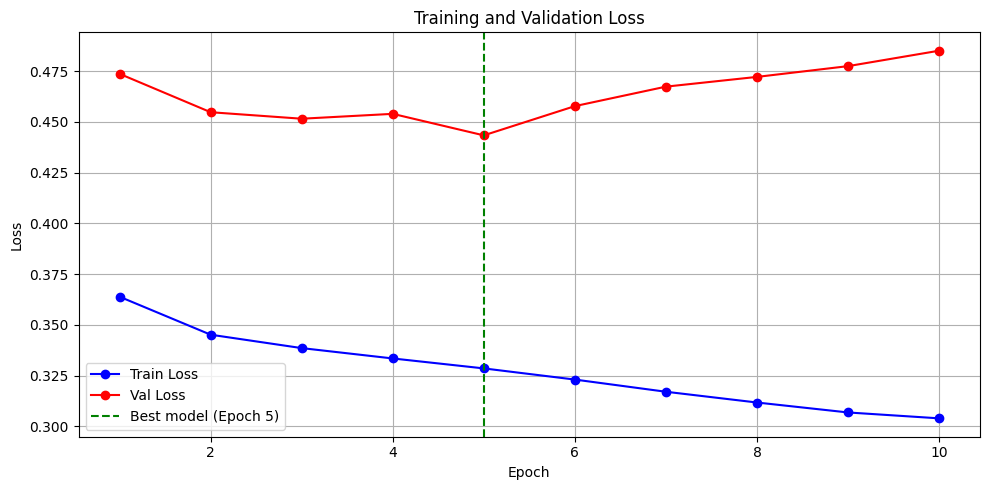

Best model: Epoch 5 — Val Loss: 0.4434


In [1]:
import matplotlib.pyplot as plt

# Training results
epochs = list(range(1, 11))
train_loss = [0.3639, 0.3452, 0.3386, 0.3335, 0.3286, 0.3231, 0.3171, 0.3118, 0.3069, 0.3040]
val_loss = [0.4737, 0.4548, 0.4516, 0.4540, 0.4434, 0.4578, 0.4674, 0.4722, 0.4775, 0.4851]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, 'b-o', label='Train Loss')
plt.plot(epochs, val_loss, 'r-o', label='Val Loss')
plt.axvline(x=5, color='green', linestyle='--', label='Best model (Epoch 5)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/metrics/training_curves.png', dpi=150)
plt.show()

print("Best model: Epoch 5 — Val Loss: 0.4434")

In [2]:
# Final metrics summary
import pandas as pd

metrics = {
    'Pathology': ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion'],
    'AUC-ROC': [0.7419, 0.8387, 0.9255, 0.9316, 0.9204]
}

df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.sort_values('AUC-ROC', ascending=False)

print("Final AUC-ROC Results (Best Model — Epoch 5)")
print("-" * 40)
print(df_metrics.to_string(index=False))
print("-" * 40)
print(f"Mean AUC-ROC: {df_metrics['AUC-ROC'].mean():.4f}")

Final AUC-ROC Results (Best Model — Epoch 5)
----------------------------------------
       Pathology  AUC-ROC
           Edema   0.9316
   Consolidation   0.9255
Pleural Effusion   0.9204
    Cardiomegaly   0.8387
     Atelectasis   0.7419
----------------------------------------
Mean AUC-ROC: 0.8716
